In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visuals
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

# XGBoost
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load data
df = pd.read_csv(
    "/kaggle/input/competitions/home-credit-default-risk/application_train.csv"
)

# Show shape
print(df.shape)

# First rows
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Target distribution
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

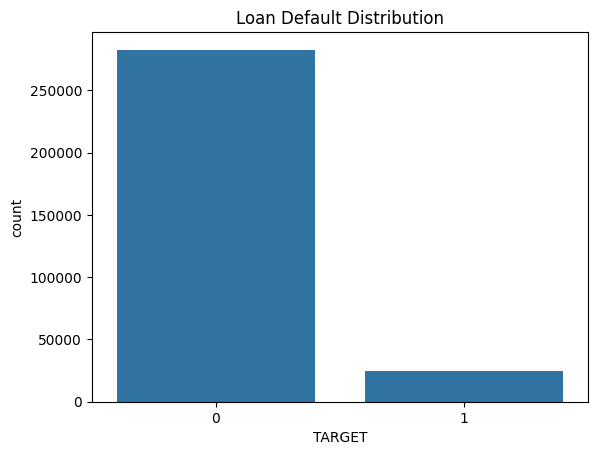

In [5]:
# Plot target
sns.countplot(x=df["TARGET"])
plt.title("Loan Default Distribution")
plt.show()

In [6]:
# Missing values
missing = df.isnull().sum()

# Top missing columns
missing.sort_values(ascending=False).head(10)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64

In [7]:
# Select columns
features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

# Create X
X = df[features]

# Create y
y = df["TARGET"]

In [8]:
# Fill missing values
X = X.fillna(X.median())

In [9]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Create model
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="logloss"
)

# Train model
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
# Predict classes
preds = model.predict(X_test)

# Predict probabilities
probs = model.predict_proba(X_test)[:, 1]

In [12]:
# Classification report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.58      0.01      0.01      4949

    accuracy                           0.92     61503
   macro avg       0.75      0.50      0.49     61503
weighted avg       0.89      0.92      0.88     61503



In [13]:
# ROC AUC
score = roc_auc_score(y_test, probs)

print("ROC AUC Score:", score)

ROC AUC Score: 0.7426100077279391


In [14]:
# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort values
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,EXT_SOURCE_3,0.346758
6,EXT_SOURCE_2,0.326504
5,EXT_SOURCE_1,0.088186
4,DAYS_EMPLOYED,0.068142
3,DAYS_BIRTH,0.059619
1,AMT_CREDIT,0.047448
2,AMT_ANNUITY,0.042474
0,AMT_INCOME_TOTAL,0.020868


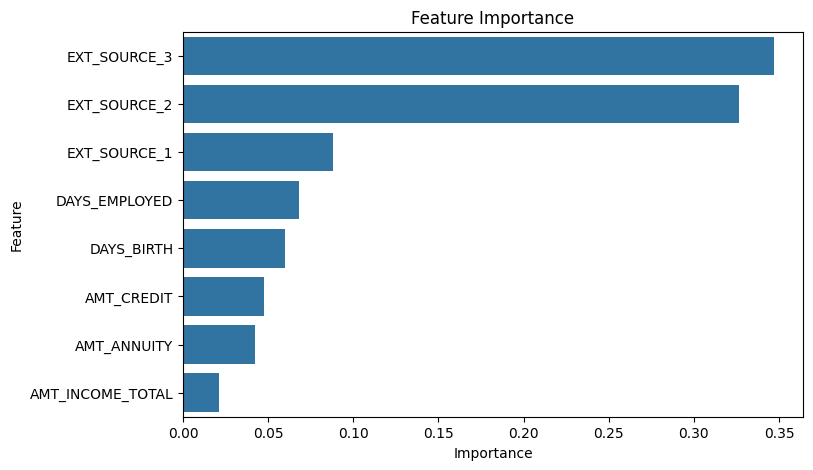

In [15]:
# Plot importance
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

# Improved Feature Engineering

In [16]:
# More useful features
features = [

    # Financial info
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",

    # Personal info
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "OCCUPATION_TYPE",

    # Age & employment
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",

    # External scores
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

# Create dataset
X = df[features]

# Target
y = df["TARGET"]

In [17]:
# Get categorical columns
cat_cols = X.select_dtypes(include="object").columns

# Show them
cat_cols

Index(['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE'],
      dtype='object')

In [18]:
# Encode categories
le = LabelEncoder()

for col in cat_cols:

    # Fill missing
    X[col] = X[col].fillna("Missing")

    # Encode text
    X[col] = le.fit_transform(X[col])

In [19]:
# Numeric columns
num_cols = X.select_dtypes(include=np.number).columns

# Fill missing values
X[num_cols] = X[num_cols].fillna(
    X[num_cols].median()
)

In [20]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
# Better XGBoost model
model = XGBClassifier(

    # Trees
    n_estimators=500,

    # Tree depth
    max_depth=5,

    # Learning speed
    learning_rate=0.03,

    # Randomness
    subsample=0.8,
    colsample_bytree=0.8,

    # Evaluation
    eval_metric="logloss",

    # Faster training
    n_jobs=-1
)

In [22]:
# Train model
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [23]:
# Predict default
preds = model.predict(X_test)

# Predict probability
probs = model.predict_proba(X_test)[:, 1]

In [24]:
# Classification metrics
print(classification_report(
    y_test,
    preds
))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.56      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



In [25]:
# ROC AUC score
auc = roc_auc_score(
    y_test,
    probs
)

print("ROC AUC:", auc)

ROC AUC: 0.7552705668962157


In [26]:
# Create importance dataframe
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": model.feature_importances_

})

# Sort
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
13,EXT_SOURCE_3,0.202908
12,EXT_SOURCE_2,0.188219
6,NAME_EDUCATION_TYPE,0.100134
4,CODE_GENDER,0.085620
11,EXT_SOURCE_1,0.069866
5,NAME_INCOME_TYPE,0.057234
3,AMT_GOODS_PRICE,0.049130
9,DAYS_BIRTH,0.045635
10,DAYS_EMPLOYED,0.041536
1,AMT_CREDIT,0.040561


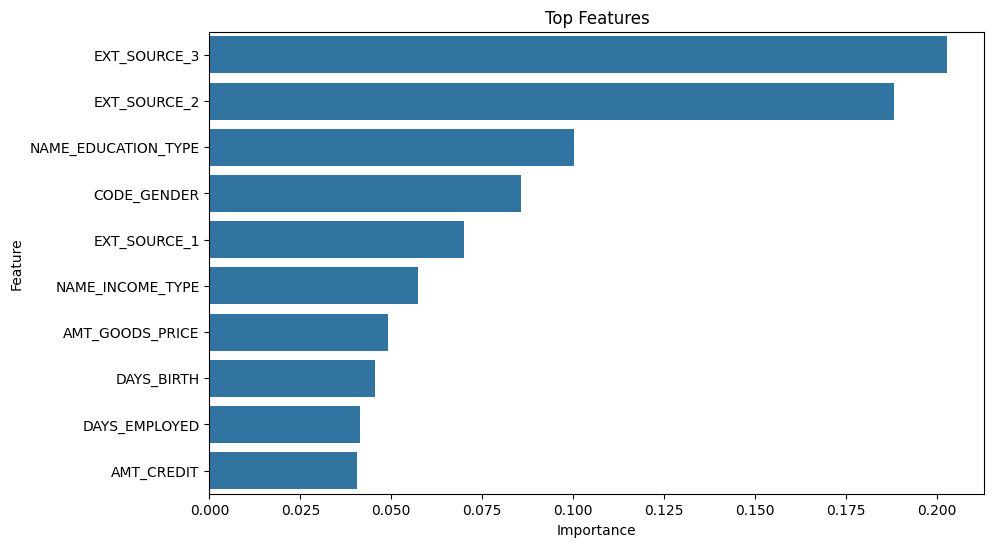

In [27]:
# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Features")

plt.show()

# Feature Engineering

In [28]:
# Copy dataset
X = df[features].copy()

# Target
y = df["TARGET"]


In [29]:
# Credit to income ratio
X["CREDIT_INCOME_RATIO"] = (
    X["AMT_CREDIT"] /
    X["AMT_INCOME_TOTAL"]
)

# Annuity to income ratio
X["ANNUITY_INCOME_RATIO"] = (
    X["AMT_ANNUITY"] /
    X["AMT_INCOME_TOTAL"]
)

# Credit to annuity ratio
X["CREDIT_ANNUITY_RATIO"] = (
    X["AMT_CREDIT"] /
    X["AMT_ANNUITY"]
)

# Employment age ratio
X["EMPLOYMENT_AGE_RATIO"] = (
    X["DAYS_EMPLOYED"] /
    X["DAYS_BIRTH"]
)

In [30]:
# One hot encode categories
X = pd.get_dummies(
    X,
    drop_first=True
)

In [31]:
# Fill missing values
X = X.fillna(X.median())

In [32]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    # Test size
    test_size=0.2,

    # Reproducibility
    random_state=42,

    # Handle imbalance
    stratify=y
)

In [33]:
# Check target balance
y.value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [34]:
# Calculate imbalance ratio
scale_pos_weight = (
    y.value_counts()[0] /
    y.value_counts()[1]
)

print(scale_pos_weight)

11.387150050352467


In [35]:
# Improved XGBoost
model = XGBClassifier(

    # Trees
    n_estimators=1000,

    # Tree depth
    max_depth=6,

    # Learning speed
    learning_rate=0.02,

    # Random row sampling
    subsample=0.8,

    # Random feature sampling
    colsample_bytree=0.8,

    # Prevent overfitting
    reg_alpha=1,
    reg_lambda=1,

    # Handle imbalance
    scale_pos_weight=scale_pos_weight,

    # Evaluation metric
    eval_metric="auc",

    # Faster processing
    n_jobs=-1,

    # Reproducibility
    random_state=42
)

In [36]:
# Train model
model.fit(

    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [37]:
# Predict classes
preds = model.predict(X_test)

# Predict probabilities
probs = model.predict_proba(X_test)[:, 1]

In [38]:
# Classification metrics
print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.66      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503



In [39]:
# ROC AUC score
auc = roc_auc_score(
    y_test,
    probs
)

print("ROC AUC:", auc)

ROC AUC: 0.7631413669787347


In [40]:
# Load main training data
train = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/application_train.csv")

# Load bureau data
bureau = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/bureau.csv")

# Load previous applications
previous = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/previous_application.csv")

# Check shapes
print(train.shape)
print(bureau.shape)
print(previous.shape)

(307511, 122)
(1716428, 17)
(1670214, 37)


In [41]:
# Select numeric columns
bureau_num = bureau.select_dtypes(include=["int64", "float64"])

# Group by customer ID
bureau_agg = bureau_num.groupby("SK_ID_CURR").agg(["mean", "max", "min", "sum"])

# Flatten column names
bureau_agg.columns = [
    "BUREAU_" + "_".join(col).upper()
    for col in bureau_agg.columns
]

# Reset index
bureau_agg = bureau_agg.reset_index()

# Preview data
bureau_agg.head()

,SK_ID_CURR,BUREAU_SK_ID_BUREAU_MEAN,BUREAU_SK_ID_BUREAU_MAX,BUREAU_SK_ID_BUREAU_MIN,BUREAU_SK_ID_BUREAU_SUM,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_SUM,BUREAU_CREDIT_DAY_OVERDUE_MEAN,...,BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_DAYS_CREDIT_UPDATE_MIN,BUREAU_DAYS_CREDIT_UPDATE_SUM,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_MAX,BUREAU_AMT_ANNUITY_MIN,BUREAU_AMT_ANNUITY_SUM
0,100001,5896633.000,5896636,5896630,41276431,-735.000000,-49,-1572,-5145,0.0,...,0.0,0.0,-93.142857,-6,-155,-652,3545.357143,10822.5,0.0,24817.5
1,100002,6153272.125,6158909,6113835,49226177,-874.000000,-103,-1437,-6992,0.0,...,0.0,0.0,-499.875000,-7,-1185,-3999,0.000000,0.0,0.0,0.0
2,100003,5885878.500,5885880,5885877,23543514,-1400.750000,-606,-2586,-5603,0.0,...,0.0,0.0,-816.000000,-43,-2131,-3264,NaN,NaN,NaN,0.0
3,100004,6829133.500,6829134,6829133,13658267,-867.000000,-408,-1326,-1734,0.0,...,0.0,0.0,-532.000000,-382,-682,-1064,NaN,NaN,NaN,0.0
4,100005,6735201.000,6735202,6735200,20205603,-190.666667,-62,-373,-572,0.0,...,0.0,0.0,-54.333333,-11,-121,-163,1420.500000,4261.5,0.0,4261.5


In [42]:
# Select numeric columns
previous_num = previous.select_dtypes(include=["int64", "float64"])

# Group by customer ID
previous_agg = previous_num.groupby("SK_ID_CURR").agg(["mean", "max", "min", "sum"])

# Flatten column names
previous_agg.columns = [
    "PREV_" + "_".join(col).upper()
    for col in previous_agg.columns
]

# Reset index
previous_agg = previous_agg.reset_index()

# Preview data
previous_agg.head()

,SK_ID_CURR,PREV_SK_ID_PREV_MEAN,PREV_SK_ID_PREV_MAX,PREV_SK_ID_PREV_MIN,PREV_SK_ID_PREV_SUM,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_SUM,PREV_AMT_APPLICATION_MEAN,...,PREV_DAYS_LAST_DUE_MIN,PREV_DAYS_LAST_DUE_SUM,PREV_DAYS_TERMINATION_MEAN,PREV_DAYS_TERMINATION_MAX,PREV_DAYS_TERMINATION_MIN,PREV_DAYS_TERMINATION_SUM,PREV_NFLAG_INSURED_ON_APPROVAL_MEAN,PREV_NFLAG_INSURED_ON_APPROVAL_MAX,PREV_NFLAG_INSURED_ON_APPROVAL_MIN,PREV_NFLAG_INSURED_ON_APPROVAL_SUM
0,100001,1.369693e+06,1369693,1369693,1369693,3951.000,3951.000,3951.000,3951.000,24835.50,...,-1619.0,-1619.0,-1612.000000,-1612.0,-1612.0,-1612.0,0.000000,0.0,0.0,0.0
1,100002,1.038818e+06,1038818,1038818,1038818,9251.775,9251.775,9251.775,9251.775,179055.00,...,-25.0,-25.0,-17.000000,-17.0,-17.0,-17.0,0.000000,0.0,0.0,0.0
2,100003,2.281150e+06,2636178,1810518,6843451,56553.990,98356.995,6737.310,169661.970,435436.50,...,-1980.0,-3163.0,-1047.333333,-527.0,-1976.0,-3142.0,0.666667,1.0,0.0,2.0
3,100004,1.564014e+06,1564014,1564014,1564014,5357.250,5357.250,5357.250,5357.250,24282.00,...,-724.0,-724.0,-714.000000,-714.0,-714.0,-714.0,0.000000,0.0,0.0,0.0
4,100005,2.176837e+06,2495675,1857999,4353674,4813.200,4813.200,4813.200,4813.200,22308.75,...,-466.0,-466.0,-460.000000,-460.0,-460.0,-460.0,0.000000,0.0,0.0,0.0


In [43]:
# Merge bureau features
train = train.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how="left"
)

# Merge previous application features
train = train.merge(
    previous_agg,
    on="SK_ID_CURR",
    how="left"
)

# Check new shape
train.shape

(307511, 254)

In [44]:
# Credit to income ratio
train["CREDIT_INCOME_RATIO"] = (
    train["AMT_CREDIT"] / train["AMT_INCOME_TOTAL"]
)

# Annuity to income ratio
train["ANNUITY_INCOME_RATIO"] = (
    train["AMT_ANNUITY"] / train["AMT_INCOME_TOTAL"]
)

# Goods price to credit ratio
train["GOODS_CREDIT_RATIO"] = (
    train["AMT_GOODS_PRICE"] / train["AMT_CREDIT"]
)

# Employment to age ratio
train["EMPLOYMENT_AGE_RATIO"] = (
    train["DAYS_EMPLOYED"] / train["DAYS_BIRTH"]
)

# Convert age to years
train["AGE_YEARS"] = (
    train["DAYS_BIRTH"] / -365
)

# Convert employment to years
train["EMPLOYMENT_YEARS"] = (
    train["DAYS_EMPLOYED"] / -365
)

In [45]:
# Target
y = train["TARGET"]

# Drop ID and target
X = train.drop(
    columns=["TARGET", "SK_ID_CURR"]
)

In [46]:
# Convert categorical columns
X = pd.get_dummies(
    X,
    drop_first=True
)

In [47]:
# Replace infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X = X.fillna(X.median())

In [48]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
# Calculate imbalance ratio
scale_pos_weight = (
    y_train.value_counts()[0] / y_train.value_counts()[1]
)

# Show ratio
print(scale_pos_weight)

11.38710976837865


In [50]:
# Create stronger model
model = XGBClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

# Train with validation monitoring
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-auc:0.68512
[100]	validation_0-auc:0.74261
[200]	validation_0-auc:0.75028
[300]	validation_0-auc:0.75794
[400]	validation_0-auc:0.76301
[500]	validation_0-auc:0.76636
[600]	validation_0-auc:0.76890
[700]	validation_0-auc:0.77080
[800]	validation_0-auc:0.77236
[900]	validation_0-auc:0.77357
[1000]	validation_0-auc:0.77464
[1100]	validation_0-auc:0.77555
[1200]	validation_0-auc:0.77622
[1300]	validation_0-auc:0.77675
[1400]	validation_0-auc:0.77718
[1500]	validation_0-auc:0.77773
[1600]	validation_0-auc:0.77805
[1700]	validation_0-auc:0.77836
[1800]	validation_0-auc:0.77865
[1900]	validation_0-auc:0.77895
[2000]	validation_0-auc:0.77920
[2100]	validation_0-auc:0.77948
[2200]	validation_0-auc:0.77967
[2300]	validation_0-auc:0.77977
[2400]	validation_0-auc:0.77995
[2500]	validation_0-auc:0.78012
[2600]	validation_0-auc:0.78024
[2700]	validation_0-auc:0.78034
[2800]	validation_0-auc:0.78046
[2900]	validation_0-auc:0.78052
[2999]	validation_0-auc:0.78057


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=3000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [51]:
# Predict probabilities
probs = model.predict_proba(X_test)[:, 1]

# Default threshold
preds = (probs >= 0.5).astype(int)

# Print report
print(classification_report(y_test, preds))

# Print AUC
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.96      0.76      0.85     56538
           1       0.19      0.66      0.30      4965

    accuracy                           0.75     61503
   macro avg       0.58      0.71      0.57     61503
weighted avg       0.90      0.75      0.80     61503

ROC AUC: 0.7805659390041372


In [52]:
from sklearn.metrics import precision_recall_curve

# Get precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Calculate F1 scores
f1_scores = 2 * (precision * recall) / (precision + recall)

# Get best threshold
best_threshold = thresholds[f1_scores[:-1].argmax()]

# Show best threshold
print("Best threshold:", best_threshold)

Best threshold: 0.638008


In [53]:
# Predict using best threshold
best_preds = (probs >= best_threshold).astype(int)

# New report
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92     56538
           1       0.26      0.46      0.34      4965

    accuracy                           0.85     61503
   macro avg       0.61      0.67      0.63     61503
weighted avg       0.89      0.85      0.87     61503



In [54]:
# Create importance dataframe
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 20
importance.head(20)

,Feature,Importance
29,EXT_SOURCE_3,0.026093
28,EXT_SOURCE_2,0.024965
260,NAME_EDUCATION_TYPE_Higher education,0.017202
243,CODE_GENDER_M,0.012114
259,NAME_INCOME_TYPE_Working,0.012007
255,NAME_INCOME_TYPE_Pensioner,0.009907
27,EXT_SOURCE_1,0.009103
238,GOODS_CREDIT_RATIO,0.008640
263,NAME_EDUCATION_TYPE_Secondary / secondary special,0.007793
209,PREV_CNT_PAYMENT_MAX,0.007529
